In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [5]:
df = pd.read_csv('StudentsPerformance.csv')

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
# How many rows and columns?
print("Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Basic statistics - mean, min, max of all score columns
print("\nBasic Statistics:")
df.describe()

Shape: (1000, 8)

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Basic Statistics:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
# Average score in each subject
print("Average Scores:")
print("Math:   ", round(df['math score'].mean(), 2))
print("Reading:", round(df['reading score'].mean(), 2))
print("Writing:", round(df['writing score'].mean(), 2))

# Add a new column - total score and average score per student
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = round(df['total score'] / 3, 2)

# Pass or Fail column (passing = average >= 40)
df['result'] = df['average score'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')

print("\nPass/Fail Count:")
print(df['result'].value_counts())

Average Scores:
Math:    66.09
Reading: 69.17
Writing: 68.05

Pass/Fail Count:
result
Pass    970
Fail     30
Name: count, dtype: int64


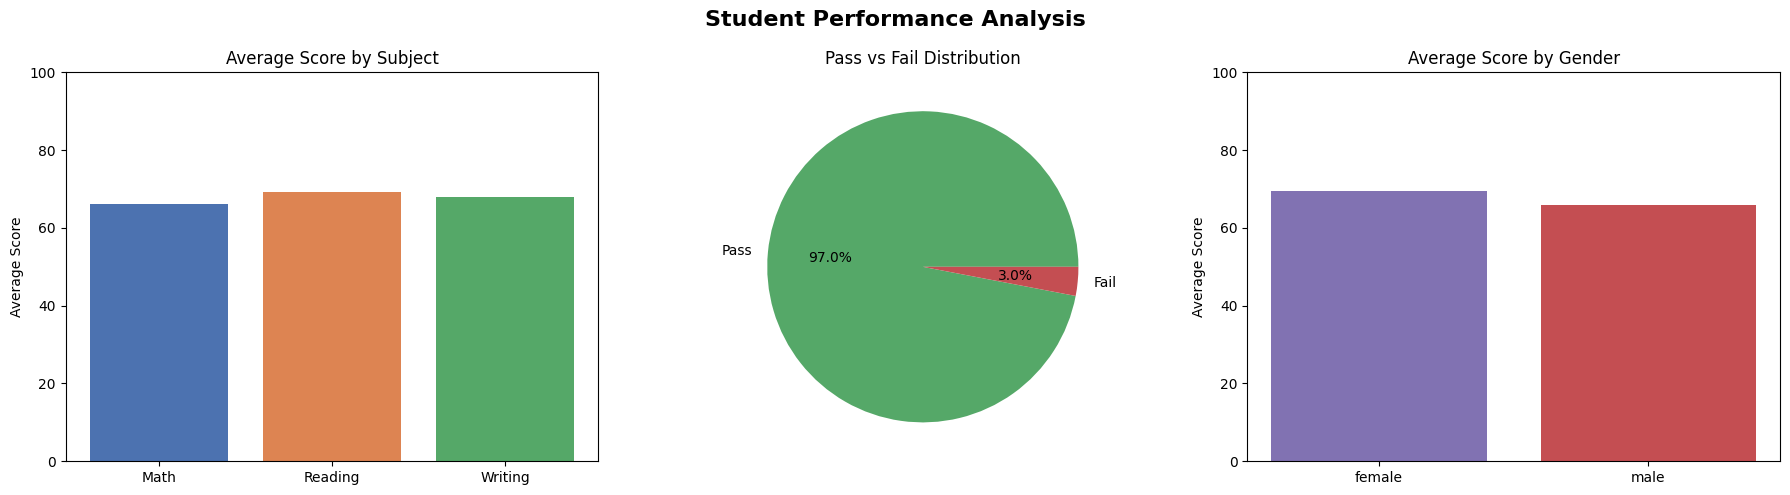

Charts saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Student Performance Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Average subject scores (Bar chart)
subjects = ['Math', 'Reading', 'Writing']
averages = [df['math score'].mean(), df['reading score'].mean(), df['writing score'].mean()]
axes[0].bar(subjects, averages, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Average Score by Subject')
axes[0].set_ylabel('Average Score')
axes[0].set_ylim(0, 100)

# Chart 2 - Pass vs Fail (Pie chart)
result_counts = df['result'].value_counts()
axes[1].pie(result_counts, labels=result_counts.index, autopct='%1.1f%%', colors=['#55A868', '#C44E52'])
axes[1].set_title('Pass vs Fail Distribution')

# Chart 3 - Score by gender (Bar chart)
gender_avg = df.groupby('gender')['average score'].mean()
axes[2].bar(gender_avg.index, gender_avg.values, color=['#8172B2', '#C44E52'])
axes[2].set_title('Average Score by Gender')
axes[2].set_ylabel('Average Score')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('performance_charts.png', dpi=150)
plt.show()
print("Charts saved!")

In [10]:
# Export full analyzed data to Excel
df.to_excel('student_report.xlsx', index=False, sheet_name='Student Data')

# Export subject averages as a summary sheet
summary = pd.DataFrame({
    'Subject': ['Math', 'Reading', 'Writing'],
    'Average Score': [
        round(df['math score'].mean(), 2),
        round(df['reading score'].mean(), 2),
        round(df['writing score'].mean(), 2)
    ]
})

with pd.ExcelWriter('student_report.xlsx', engine='openpyxl', mode='a') as writer:
    summary.to_excel(writer, sheet_name='Summary', index=False)

print("Excel report saved as student_report.xlsx")


Excel report saved as student_report.xlsx


In [11]:
# Create a database and save data into it
conn = sqlite3.connect('students.db')

# Save full data to a table called 'performance'
df.to_sql('performance', conn, if_exists='replace', index=False)

# Run a SQL query on it
query = pd.read_sql_query("SELECT gender, ROUND(AVG(`average score`), 2) as avg_score FROM performance GROUP BY gender", conn)

print("SQL Query Result - Average Score by Gender:")
print(query)

# Save pass/fail summary to another table
pass_fail = df['result'].value_counts().reset_index()
pass_fail.columns = ['result', 'count']
pass_fail.to_sql('pass_fail_summary', conn, if_exists='replace', index=False)

conn.close()
print("\nDatabase saved as students.db")


SQL Query Result - Average Score by Gender:
   gender  avg_score
0  female      69.57
1    male      65.84

Database saved as students.db


In [12]:
# Insight 1 - Impact of test preparation course
prep_impact = df.groupby('test preparation course')['average score'].mean().round(2)
print("Impact of Test Preparation Course:")
print(prep_impact)

# Insight 2 - Top performing group
top_group = df.groupby('race/ethnicity')['average score'].mean().round(2).sort_values(ascending=False)
print("\nAverage Score by Race/Ethnicity:")
print(top_group)

# Insight 3 - Parental education impact
parent_impact = df.groupby('parental level of education')['average score'].mean().round(2).sort_values(ascending=False)
print("\nImpact of Parental Education on Score:")
print(parent_impact)

Impact of Test Preparation Course:
test preparation course
completed    72.67
none         65.04
Name: average score, dtype: float64

Average Score by Race/Ethnicity:
race/ethnicity
group E    72.75
group D    69.18
group C    67.13
group B    65.47
group A    62.99
Name: average score, dtype: float64

Impact of Parental Education on Score:
parental level of education
master's degree       73.60
bachelor's degree     71.92
associate's degree    69.57
some college          68.48
some high school      65.11
high school           63.10
Name: average score, dtype: float64
